#Inteligencia Artificial para Problemas Inversos


Oscilador armónico amortiguado: $m\ddot{x}(t) + \gamma\dot{x}(t) + kx(t) = 0$, con $m=1$, $x(0)=1$, $\dot{x}(0)=0$.

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(42)

---
## Parte (b) — Generación del dataset

In [50]:
N_signals = 3000
Nt        = 1000
t_span    = (0.0, 10.0)
t_eval    = np.linspace(*t_span, Nt)
sigma_b   = 0.02          # nivel de ruido para la parte (b)


gamma_samples = rng.uniform(0.05, 1.0,  N_signals)
k_samples     = rng.uniform(1.0,  5.0,  N_signals)


def amortiguado(gamma, k, t_eval, sigma=0.0, rng=None):
    """Resuelve m x'' + gamma x' + k x = 0, m=1, x(0)=1, x'(0)=0."""
    def ode(t, y):
        x, v = y
        return [v, -gamma * v - k * x]

    sol = solve_ivp(ode, (t_eval[0], t_eval[-1]), [1.0, 0.0],
                    t_eval=t_eval, method='RK45',
                    rtol=1e-8, atol=1e-10, dense_output=False)
    x = sol.y[0]
    if sigma > 0 and rng is not None:
        x = x + rng.normal(0, sigma, size=x.shape)
    return x

# ── Genero el dataset ───────────────────────────────────────────────────────

X_data = np.zeros((N_signals, Nt))
for i in range(N_signals):
    X_data[i] = amortiguado(
        gamma_samples[i], k_samples[i], t_eval, sigma=sigma_b, rng=rng)
        
theta_data = np.column_stack([gamma_samples, k_samples])


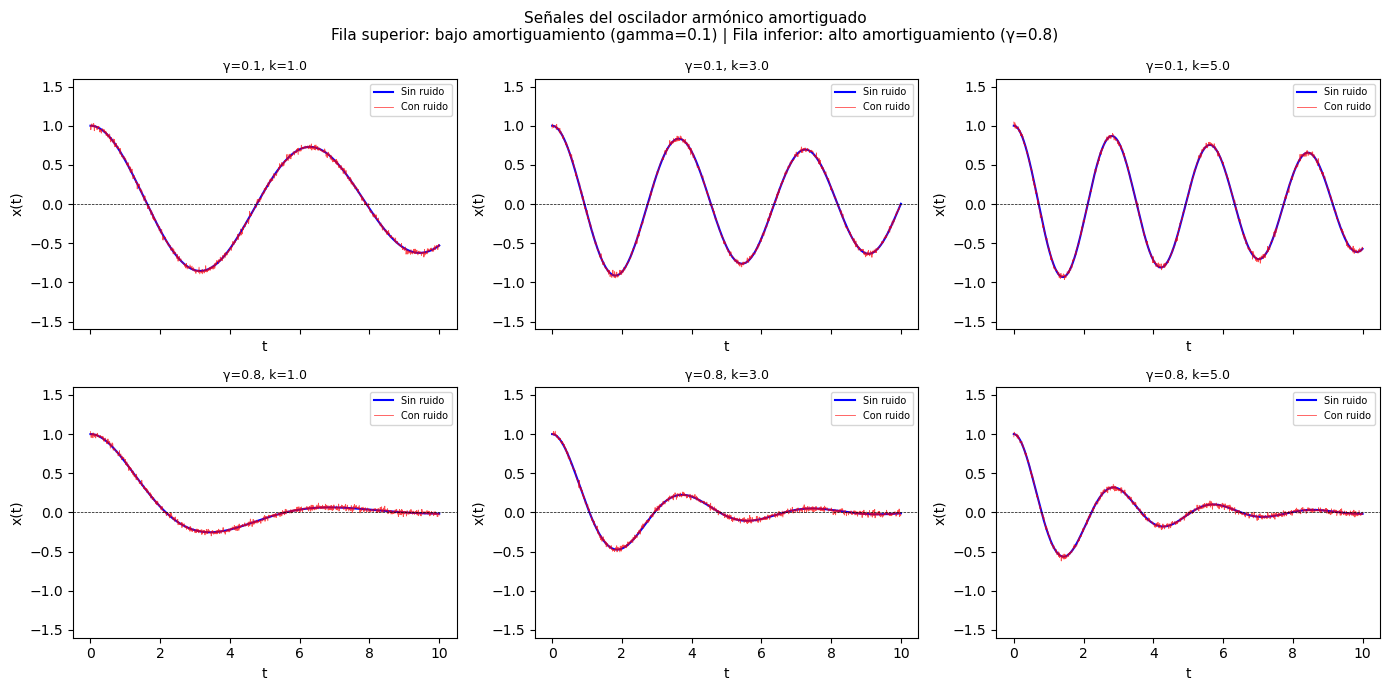


Observaciones:
  • Mayor k: mayor frecuencia de oscilación (período más corto).
  • Mayor gamma: mayor amortiguamiento (la amplitud decae más rápido).
  • Ambos efectos son claramente distinguibles en la señal, lo que sugiere
    que un modelo de ML puede aprender a separarlos.



In [59]:
# visualización de agulas seña
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
examples = [
    (0.1, 1.0, 'Bajo amort., baja k\n(lenta, poco amort.)'),
    (0.1, 3.0, 'Bajo amort., media k\n(más rápida, poco amort.)'),
    (0.1, 5.0, 'Bajo amort., alta k\n(más rápida aún)'),
    (0.8, 1.0, 'Alto amort., baja k\n(lenta, muy amort.)'),
    (0.8, 3.0, 'Alto amort., media k'),
    (0.8, 5.0, 'Alto amort., alta k'),
]

for ax, (g, k, title) in zip(axes.flat, examples):
    x_clean = amortiguado(g, k, t_eval, sigma=0.0)
    x_noisy = amortiguado(g, k, t_eval, sigma=sigma_b, rng=rng)
    ax.plot(t_eval, x_clean, 'b-',  lw=1.5, label='Sin ruido')
    ax.plot(t_eval, x_noisy, 'r-',  lw=0.6, alpha=0.7, label='Con ruido')
    ax.set_title(f'γ={g}, k={k}', fontsize=9)
    ax.set_ylim(-1.6, 1.6)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.legend(fontsize=7, loc='upper right')
    ax.set_xlabel('t')
    ax.set_ylabel('x(t)')

fig.suptitle('Señales del oscilador armónico amortiguado\n'
             'Fila superior: bajo amortiguamiento (gamma=0.1) | Fila inferior: alto amortiguamiento (γ=0.8)',
             fontsize=11)
plt.tight_layout()

plt.show()

print('''
Observaciones:
  • Mayor k: mayor frecuencia de oscilación (período más corto).
  • Mayor gamma: mayor amortiguamiento (la amplitud decae más rápido).
  • Ambos efectos son claramente distinguibles en la señal, lo que sugiere
    que un modelo de ML puede aprender a separarlos.
''')

---
## Parte (c) — Entrenamiento y evaluación de modelos

In [52]:
#  80/20 ─────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X_data, theta_data, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

def rmse_report(nombre, y_true, y_pred):
    rmse_g = np.sqrt(mean_squared_error(y_true[:, 0], y_pred[:, 0]))
    rmse_k = np.sqrt(mean_squared_error(y_true[:, 1], y_pred[:, 1]))
    print(f'{nombre:<30s}  RMSE_γ = {rmse_g:.5f}   RMSE_k = {rmse_k:.5f}')
    return rmse_g, rmse_k

In [53]:
# ── Modelo 1: Random Forest ──────────────────────────────────────────────────

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
    min_samples_leaf=2
)
rf.fit(X_train, y_train)

rf_pred_train = rf.predict(X_train)
rf_pred_test  = rf.predict(X_test)
print('Rendimiento Random Forest:')
rmse_report('  Train', y_train, rf_pred_train)
rf_rmse_g, rf_rmse_k = rmse_report('  Test ', y_test,  rf_pred_test)

Rendimiento Random Forest:
  Train                         RMSE_γ = 0.00814   RMSE_k = 0.03460
  Test                          RMSE_γ = 0.01677   RMSE_k = 0.02612


In [54]:

mlp = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    max_iter=500,
    learning_rate_init=1e-3,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)
mlp.fit(X_train_sc, y_train)

mlp_pred_train = mlp.predict(X_train_sc)
mlp_pred_test  = mlp.predict(X_test_sc)
print('Rendimiento MLP:')
rmse_report('  Train', y_train, mlp_pred_train)
mlp_rmse_g, mlp_rmse_k = rmse_report('  Test ', y_test,  mlp_pred_test)

Rendimiento MLP:
  Train                         RMSE_γ = 0.04427   RMSE_k = 0.06339
  Test                          RMSE_γ = 0.05968   RMSE_k = 0.09362


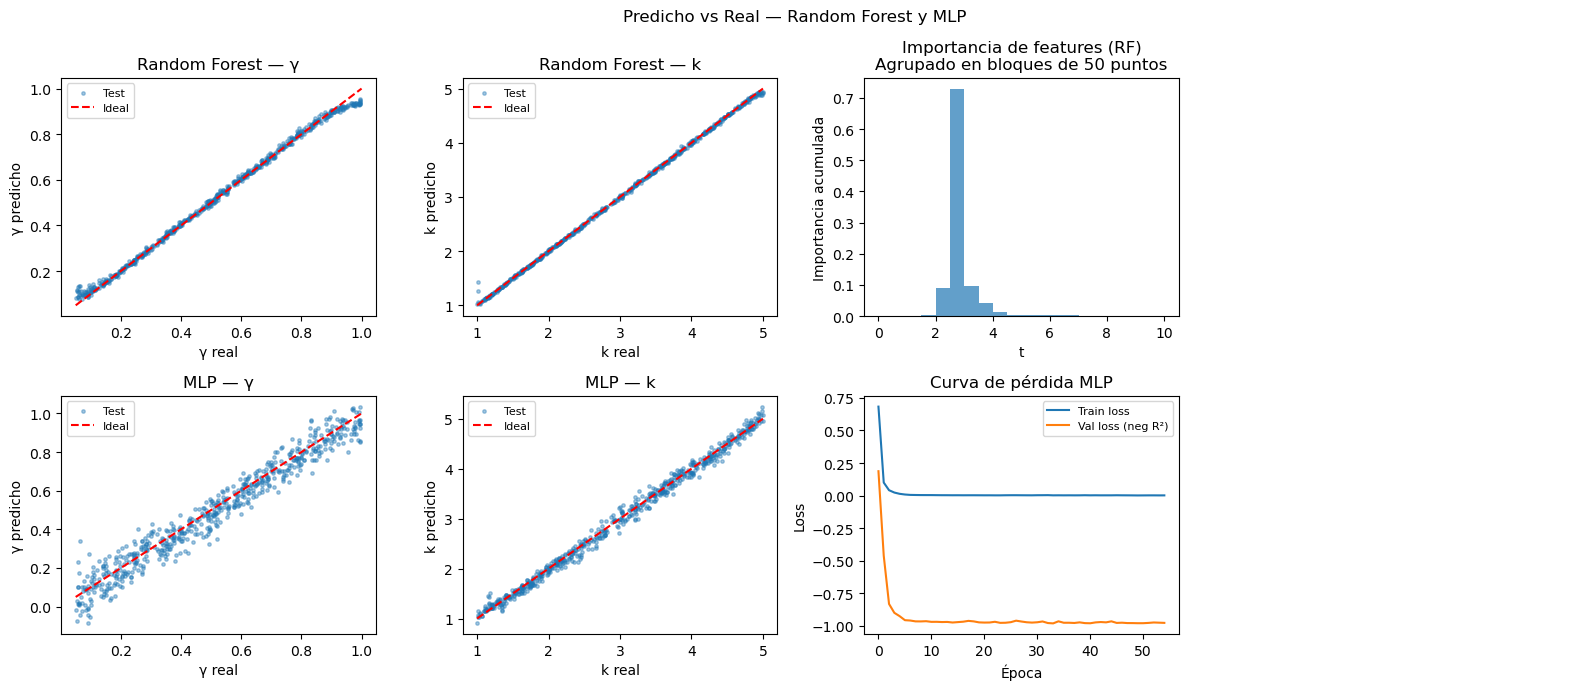

In [55]:

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
configs = [
    (rf_pred_test[:,0],  y_test[:,0],  'RF — γ',  'γ real', 'γ predicho',  (0.05,1.0)),
    (rf_pred_test[:,1],  y_test[:,1],  'RF — k',  'k real', 'k predicho',  (1.0, 5.0)),
    (mlp_pred_test[:,0], y_test[:,0],  'MLP — γ', 'γ real', 'γ predicho',  (0.05,1.0)),
    (mlp_pred_test[:,1], y_test[:,1],  'MLP — k', 'k real', 'k predicho',  (1.0, 5.0)),
]

for row, (pred_train_p, pred_test_p, label_train, label_test) in enumerate([
    (rf_pred_train, rf_pred_test, 'Random Forest', 'RF'),
    (mlp_pred_train, mlp_pred_test, 'MLP', 'MLP')
]):
    for col, (param_idx, pname, lims) in enumerate([(0,'γ',(0.05,1.0)),(1,'k',(1.0,5.0))]):
        ax = axes[row, col]
        ax.scatter(y_test[:,param_idx], pred_test_p[:,param_idx],
                   s=6, alpha=0.4, label='Test')
        lo, hi = lims
        ax.plot([lo,hi],[lo,hi],'r--',lw=1.5, label='Ideal')
        ax.set_xlabel(f'{pname} real'); ax.set_ylabel(f'{pname} predicho')
        ax.set_title(f'{label_train} — {pname}')
        ax.legend(fontsize=8)

    # curva de pérdida para MLP
    if row == 1:
        ax = axes[row, 2]
        ax.plot(mlp.loss_curve_,  label='Train loss')
        if mlp.validation_scores_ is not None:
            ax.plot([-s for s in mlp.validation_scores_], label='Val loss (neg R²)')
        ax.set_xlabel('Época'); ax.set_ylabel('Loss')
        ax.set_title('Curva de pérdida MLP'); ax.legend(fontsize=8)
        axes[row, 3].axis('off')
    else:
        importances = rf.feature_importances_
        # agrupamos en bloques de 50 para visualizar
        block = 50
        imp_block = importances.reshape(-1, block).sum(axis=1)
        t_block   = t_eval[::block][:len(imp_block)]
        ax = axes[row, 2]
        ax.bar(t_block, imp_block, width=t_eval[block]-t_eval[0], align='edge', alpha=0.7)
        ax.set_xlabel('t'); ax.set_ylabel('Importancia acumulada')
        ax.set_title('Importancia de features (RF)\nAgrupado en bloques de 50 puntos')
        axes[row, 3].axis('off')

plt.suptitle('Predicho vs Real — Random Forest y MLP', fontsize=12)
plt.tight_layout()

plt.show()

In [60]:

print(f'{"Modelo":<22} {"RMSE_γ":>10} {"RMSE_k":>10}')
print('-'*55)
print(f'{"Random Forest":<22} {rf_rmse_g:>10.5f} {rf_rmse_k:>10.5f}')
print(f'{"MLP":<22} {mlp_rmse_g:>10.5f} {mlp_rmse_k:>10.5f}')
print('='*55)

Modelo                     RMSE_γ     RMSE_k
-------------------------------------------------------
Random Forest             0.01677    0.02612
MLP                       0.05968    0.09362


---
## Parte (d) — Efecto del nivel de ruido σ

In [57]:
sigma_values = [0.0, 0.01, 0.02, 0.05, 0.10]

results = {s: {'rf': {}, 'mlp': {}} for s in sigma_values}

# Reutilizo los mismos (gamma, k) para todos los niveles de ruido
for sigma in sigma_values:
    print(f'\nσ = {sigma}')

    # Genero señales con este nivel de ruido
    X_s = np.zeros((N_signals, Nt))
    for i in range(N_signals):
        X_s[i] = amortiguado(
            gamma_samples[i], k_samples[i], t_eval,
            sigma=sigma, rng=rng)

    Xtr, Xte, ytr, yte = train_test_split(
        X_s, theta_data, test_size=0.2, random_state=42)

    sc = StandardScaler()
    Xtr_sc = sc.fit_transform(Xtr)
    Xte_sc = sc.transform(Xte)

    # Random Forest
    rf_s = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42,
                                  min_samples_leaf=2)
    rf_s.fit(Xtr, ytr)
    pte_rf = rf_s.predict(Xte)
    ptr_rf = rf_s.predict(Xtr)

    results[sigma]['rf']['test_g']  = np.sqrt(mean_squared_error(yte[:,0], pte_rf[:,0]))
    results[sigma]['rf']['test_k']  = np.sqrt(mean_squared_error(yte[:,1], pte_rf[:,1]))
    results[sigma]['rf']['train_g'] = np.sqrt(mean_squared_error(ytr[:,0], ptr_rf[:,0]))
    results[sigma]['rf']['train_k'] = np.sqrt(mean_squared_error(ytr[:,1], ptr_rf[:,1]))

    # MLP
    mlp_s = MLPRegressor(hidden_layer_sizes=(256,128,64), activation='relu',
                          solver='adam', max_iter=500, learning_rate_init=1e-3,
                          early_stopping=True, validation_fraction=0.1,
                          n_iter_no_change=20, random_state=42)
    mlp_s.fit(Xtr_sc, ytr)
    pte_mlp = mlp_s.predict(Xte_sc)
    ptr_mlp = mlp_s.predict(Xtr_sc)

    results[sigma]['mlp']['test_g']  = np.sqrt(mean_squared_error(yte[:,0], pte_mlp[:,0]))
    results[sigma]['mlp']['test_k']  = np.sqrt(mean_squared_error(yte[:,1], pte_mlp[:,1]))
    results[sigma]['mlp']['train_g'] = np.sqrt(mean_squared_error(ytr[:,0], ptr_mlp[:,0]))
    results[sigma]['mlp']['train_k'] = np.sqrt(mean_squared_error(ytr[:,1], ptr_mlp[:,1]))

    rmse_report('  RF  test ', yte, pte_rf)
    rmse_report('  MLP test ', yte, pte_mlp)



σ = 0.0
  RF  test                      RMSE_γ = 0.01283   RMSE_k = 0.01026
  MLP test                      RMSE_γ = 0.02147   RMSE_k = 0.04179

σ = 0.01
  RF  test                      RMSE_γ = 0.01395   RMSE_k = 0.01299
  MLP test                      RMSE_γ = 0.03771   RMSE_k = 0.05132

σ = 0.02
  RF  test                      RMSE_γ = 0.01709   RMSE_k = 0.02257
  MLP test                      RMSE_γ = 0.04320   RMSE_k = 0.07801

σ = 0.05
  RF  test                      RMSE_γ = 0.03137   RMSE_k = 0.04268
  MLP test                      RMSE_γ = 0.08288   RMSE_k = 0.14292

σ = 0.1
  RF  test                      RMSE_γ = 0.05663   RMSE_k = 0.09030
  MLP test                      RMSE_γ = 0.13613   RMSE_k = 0.24434


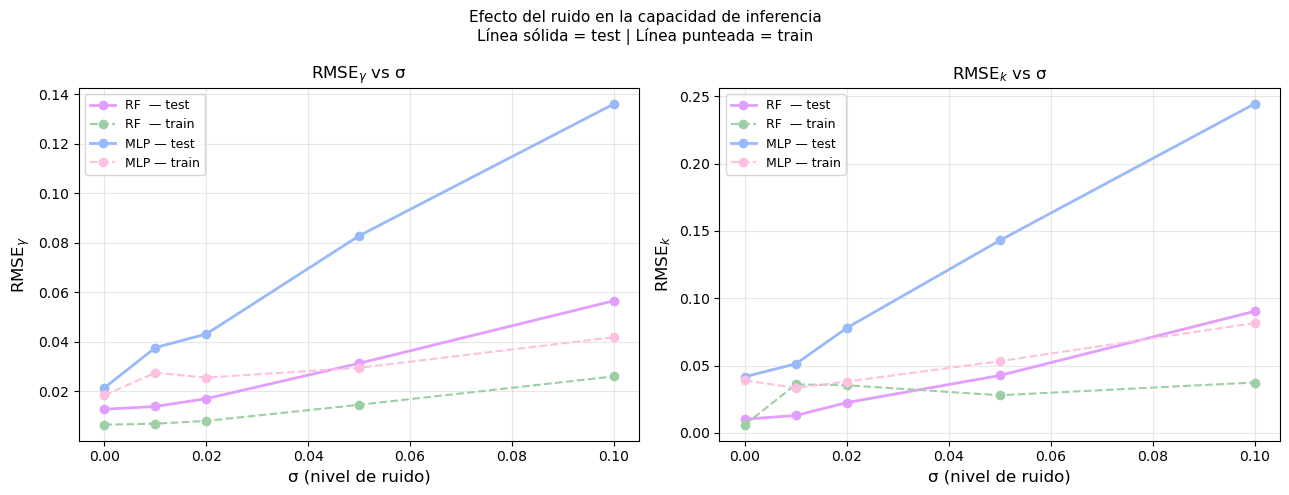

In [58]:
# ── Gráfico RMSE vs σ ────────────────────────────────────────────────────────
sigmas = sigma_values

def extract(model, split, param):
    return [results[s][model][f'{split}_{param}'] for s in sigmas]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, param, label in zip(axes, ['g','k'], ['γ','k']):
    ax.plot(sigmas, extract('rf',  'test',  param), 'o-', color='#E29EFF', lw=2,  label='RF  — test')
    ax.plot(sigmas, extract('rf',  'train', param), 'o--',color = '#9DCFA5', lw=1.5, label='RF  — train')
    ax.plot(sigmas, extract('mlp', 'test',  param), 'o-' ,color ='#98B9FA' ,lw=2,  label='MLP — test')
    ax.plot(sigmas, extract('mlp', 'train', param), 'o--' ,color ='#FFBFE0', lw=1.5, label='MLP — train')
    ax.set_xlabel('σ (nivel de ruido)', fontsize=12)
    ax.set_ylabel(f'RMSE$_{{{label}}}$', fontsize=12)
    ax.set_title(f'RMSE$_{{{label}}}$ vs σ', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Efecto del ruido en la capacidad de inferencia\n'
             'Línea sólida = test | Línea punteada = train', fontsize=11)
plt.tight_layout()
plt.show()


**¿Qué parámetro es más difícil de inferir?**

En general, $\gamma$ resulta más difícil de inferir que $k$. La razón física es que:
- $k$ controla la **frecuencia** de oscilación, que es un efecto fuerte y observable desde el principio de la señal.
- $\gamma$ controla la **tasa de decaimiento** de la amplitud, un efecto más sutil que solo se hace evidente sobre escalas de tiempo más largas. Con ruido, la envolvente del decaimiento queda enmascarada.

**Sobreajuste :**

El sobreajuste se manifiesta cuando el error de entrenamiento (línea punteada) es significativamente menor que el error de validación/test (línea sólida). Ocurre porque el modelo memoriza los datos de entrenamiento, incluyendo el ruido, en lugar de aprender el patrón subyacente. Al aumentar $\sigma$:
1. El RMSE de test crece (el ruido dificulta la inferencia).
2. La brecha train–test puede aumentar, indicando mayor sobreajuste.

El Random Forest tiende a mostrar mayor sobreajuste (RMSE train ≈ 0 para $\sigma = 0$), mientras que el MLP con early stopping lo controla mejor.

**Conclusión:** para $\sigma = 0$ ambos modelos recuperan los parámetros casi perfectamente, confirmando que el problema inverso es resoluble cuando los datos son exactos. A medida que $\sigma$ aumenta, el rendimiento se degrada gradualmente, siendo $\gamma$ el parámetro más sensible al ruido.